# Análise Exploratória de Dados — RoCoLe (features tabulares)

**TCD — Aprendizado de Máquina / PPGEELT-UFU**  
**Autora:** Natalia Salete Rodrigues  
**Dataset:** RoCoLe (Robusta Coffee Leaf), 1.560 imagens de folhas de café robusta em condições reais de cultivo, convertidas em 26 features tabulares (cor, textura, qualidade).

Esta AED alimenta o relatório da Etapa 01 (Definição e Exploração) e já serve como base para os experimentos clássicos no KNIME nas etapas seguintes.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style='whitegrid', context='paper')
ROOT = Path('..').resolve()
OUT = ROOT / 'outputs'
FIGS = OUT / 'figs'
FIGS.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(OUT / 'rocole_features.csv')
print(f'Linhas: {len(df)} | Colunas: {df.shape[1]}')
df.head()

Matplotlib is building the font cache; this may take a moment.


Linhas: 1560 | Colunas: 29


,file,width,height,aspect_ratio,r_mean,r_std,g_mean,g_std,b_mean,b_std,...,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,glcm_dissimilarity,glcm_asm,brightness,laplacian_var,binary_label,multiclass_label
0,C1P1H1.jpg,1152,2048,0.5625,106.628769,39.607902,138.450438,41.329984,91.435096,37.102691,...,4.685313,0.578663,0.113902,0.892149,1.325464,0.013039,123.575893,871.908001,healthy,healthy
1,C1P2E2.jpg,1152,2048,0.5625,101.244445,46.463913,122.075249,57.011354,85.053125,37.648486,...,5.791696,0.554347,0.100787,0.921347,1.485679,0.010187,111.622270,1130.099762,unhealthy,rust_level_2
2,C1P2H1.jpg,1152,2048,0.5625,98.884092,41.533459,123.948747,49.842402,86.942986,44.682117,...,4.894912,0.564922,0.102081,0.915456,1.368395,0.010456,112.228949,913.245866,healthy,healthy
3,C1P3E1.jpg,1152,2048,0.5625,110.577782,37.237462,131.825764,47.979514,94.021265,31.939424,...,4.954482,0.536696,0.105902,0.904345,1.454966,0.011250,121.160800,807.448759,healthy,healthy
4,C1P3E2.jpg,1152,2048,0.5625,92.386976,49.082957,114.899459,52.804608,69.948644,33.782237,...,4.583913,0.620812,0.111243,0.932385,1.200136,0.012407,103.041269,973.705153,unhealthy,rust_level_2


## 1. Caracterização e estatísticas descritivas

In [2]:
FEATURES = [c for c in df.columns if c not in ('file', 'binary_label', 'multiclass_label')]
print(f'{len(FEATURES)} features numéricas')
df[FEATURES].describe().T.round(3)

26 features numéricas


,count,mean,std,min,25%,50%,75%,max
width,1560.0,1254.104,567.223,720.000,720.000,1152.000,1152.000,2322.000
height,1560.0,2229.518,1008.396,1280.000,1280.000,2048.000,2048.000,4128.000
aspect_ratio,1560.0,0.562,0.000,0.562,0.562,0.562,0.562,0.562
r_mean,1560.0,105.348,14.123,58.031,95.771,105.386,114.291,157.614
r_std,1560.0,51.197,9.363,23.508,44.197,50.950,58.020,78.873
g_mean,1560.0,129.677,16.018,77.381,119.632,129.797,138.605,182.426
g_std,1560.0,50.125,8.908,24.660,43.795,50.226,56.810,82.264
b_mean,1560.0,75.999,19.938,21.025,62.403,76.595,89.762,132.870
b_std,1560.0,48.529,10.218,24.265,41.614,46.970,54.138,96.599
h_mean,1560.0,48.017,13.153,22.303,38.491,44.821,55.805,90.291


In [3]:
print('Valores ausentes por coluna:')
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().any().any() else 'Nenhum')

Valores ausentes por coluna:
Nenhum


## 2. Distribuição das classes

O enunciado do TCD pede interpretação estatística. **Atenção especial ao desbalanceamento multiclasse** — é exatamente o gap apontado por Santos et al. (2023) como limitador da acurácia (78,03%).

/var/folders/g8/73n4kmgs5_5dqn0b5h9hvf_00000gq/T/ipykernel_76598/113244315.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='binary_label', order=order_bin, ax=axes[0], palette='Set2')
/var/folders/g8/73n4kmgs5_5dqn0b5h9hvf_00000gq/T/ipykernel_76598/113244315.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='multiclass_label', order=order_mc, ax=axes[1], palette='Set3')


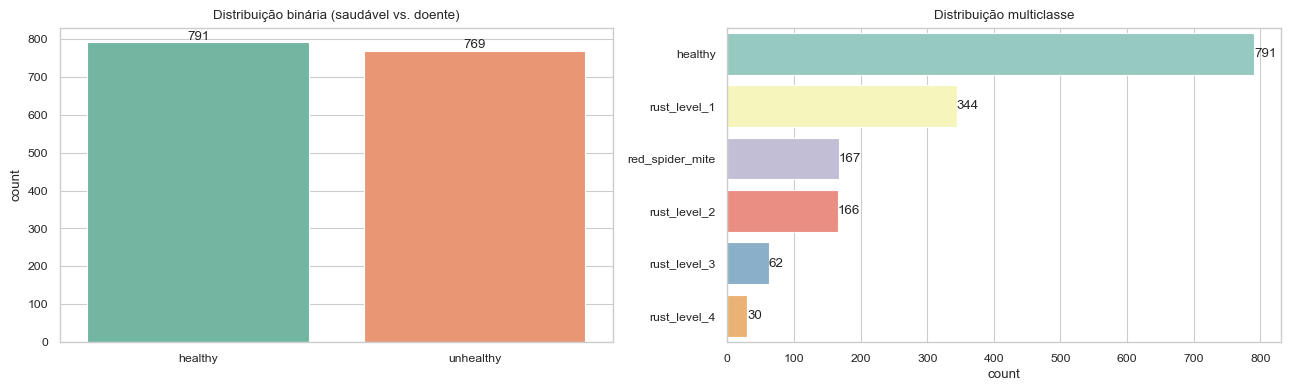


Proporção multiclasse:
multiclass_label
healthy            50.71%
rust_level_1       22.05%
red_spider_mite    10.71%
rust_level_2       10.64%
rust_level_3        3.97%
rust_level_4        1.92%
Name: proportion, dtype: object


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order_bin = df['binary_label'].value_counts().index
sns.countplot(data=df, x='binary_label', order=order_bin, ax=axes[0], palette='Set2')
axes[0].set_title('Distribuição binária (saudável vs. doente)')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

order_mc = df['multiclass_label'].value_counts().index
sns.countplot(data=df, y='multiclass_label', order=order_mc, ax=axes[1], palette='Set3')
axes[1].set_title('Distribuição multiclasse')
axes[1].set_ylabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center')

plt.tight_layout()
plt.savefig(FIGS / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nProporção multiclasse:')
print((df['multiclass_label'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

## 3. Dimensões e qualidade das imagens

Característica importante das condições reais de cultivo: há variabilidade de resolução, brilho e nitidez, diferente de datasets controlados como PlantVillage.

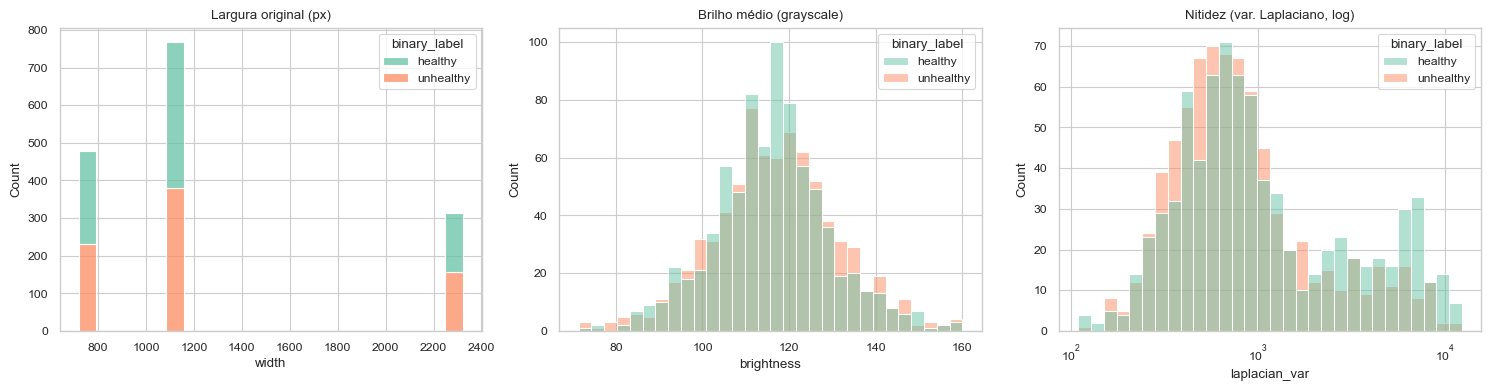

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df, x='width', hue='binary_label', multiple='stack', ax=axes[0], palette='Set2')
axes[0].set_title('Largura original (px)')

sns.histplot(df, x='brightness', hue='binary_label', multiple='layer', alpha=0.5, ax=axes[1], palette='Set2', bins=30)
axes[1].set_title('Brilho médio (grayscale)')

sns.histplot(df, x='laplacian_var', hue='binary_label', multiple='layer', alpha=0.5, ax=axes[2], palette='Set2', bins=30, log_scale=(True, False))
axes[2].set_title('Nitidez (var. Laplaciano, log)')

plt.tight_layout()
plt.savefig(FIGS / 'image_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Histogramas das features por classe

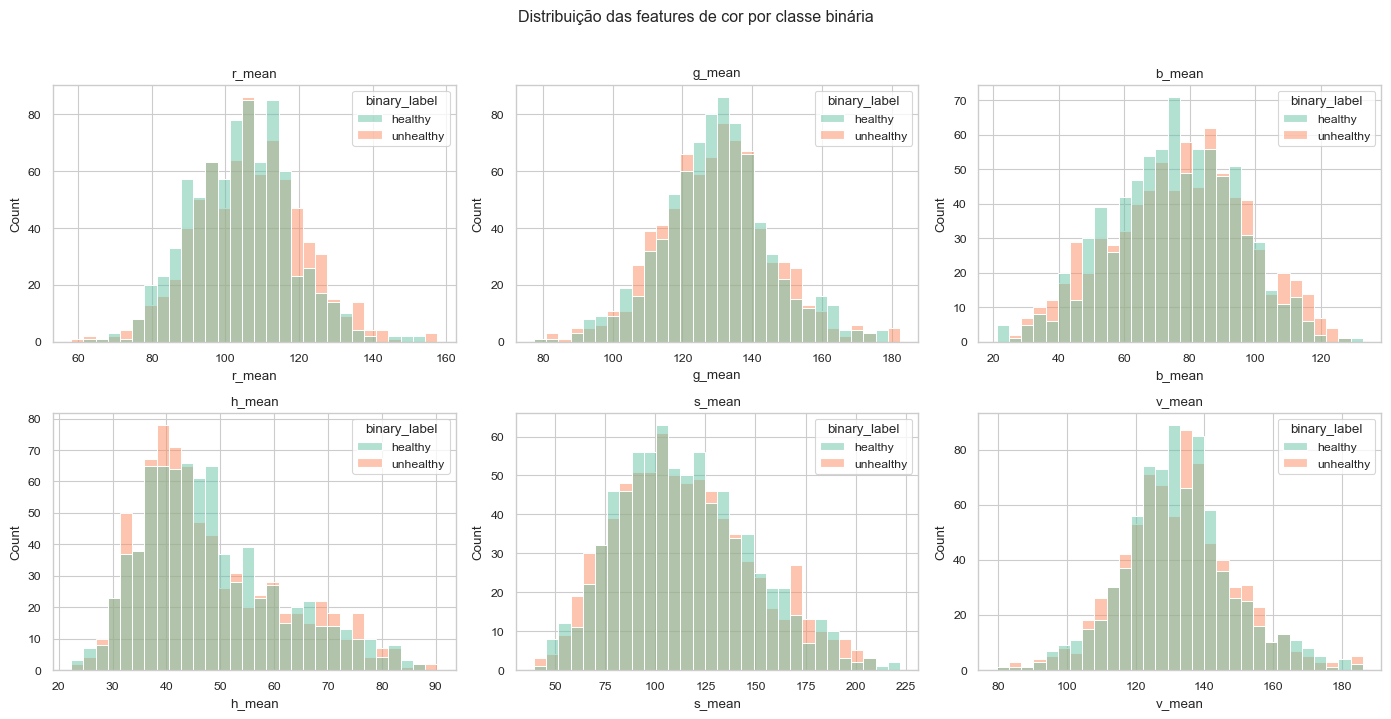

In [6]:
COLOR_FEATS = ['r_mean', 'g_mean', 'b_mean', 'h_mean', 's_mean', 'v_mean']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, COLOR_FEATS):
    sns.histplot(df, x=feat, hue='binary_label', multiple='layer', alpha=0.5, ax=ax, palette='Set2', bins=30)
    ax.set_title(feat)
plt.suptitle('Distribuição das features de cor por classe binária', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'color_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Boxplots — features mais discriminativas

/var/folders/g8/73n4kmgs5_5dqn0b5h9hvf_00000gq/T/ipykernel_76598/1431780479.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='multiclass_label', y=feat, order=mc_order, ax=ax, palette='Set3')
/var/folders/g8/73n4kmgs5_5dqn0b5h9hvf_00000gq/T/ipykernel_76598/1431780479.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='multiclass_label', y=feat, order=mc_order, ax=ax, palette='Set3')
/var/folders/g8/73n4kmgs5_5dqn0b5h9hvf_00000gq/T/ipykernel_76598/1431780479.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df

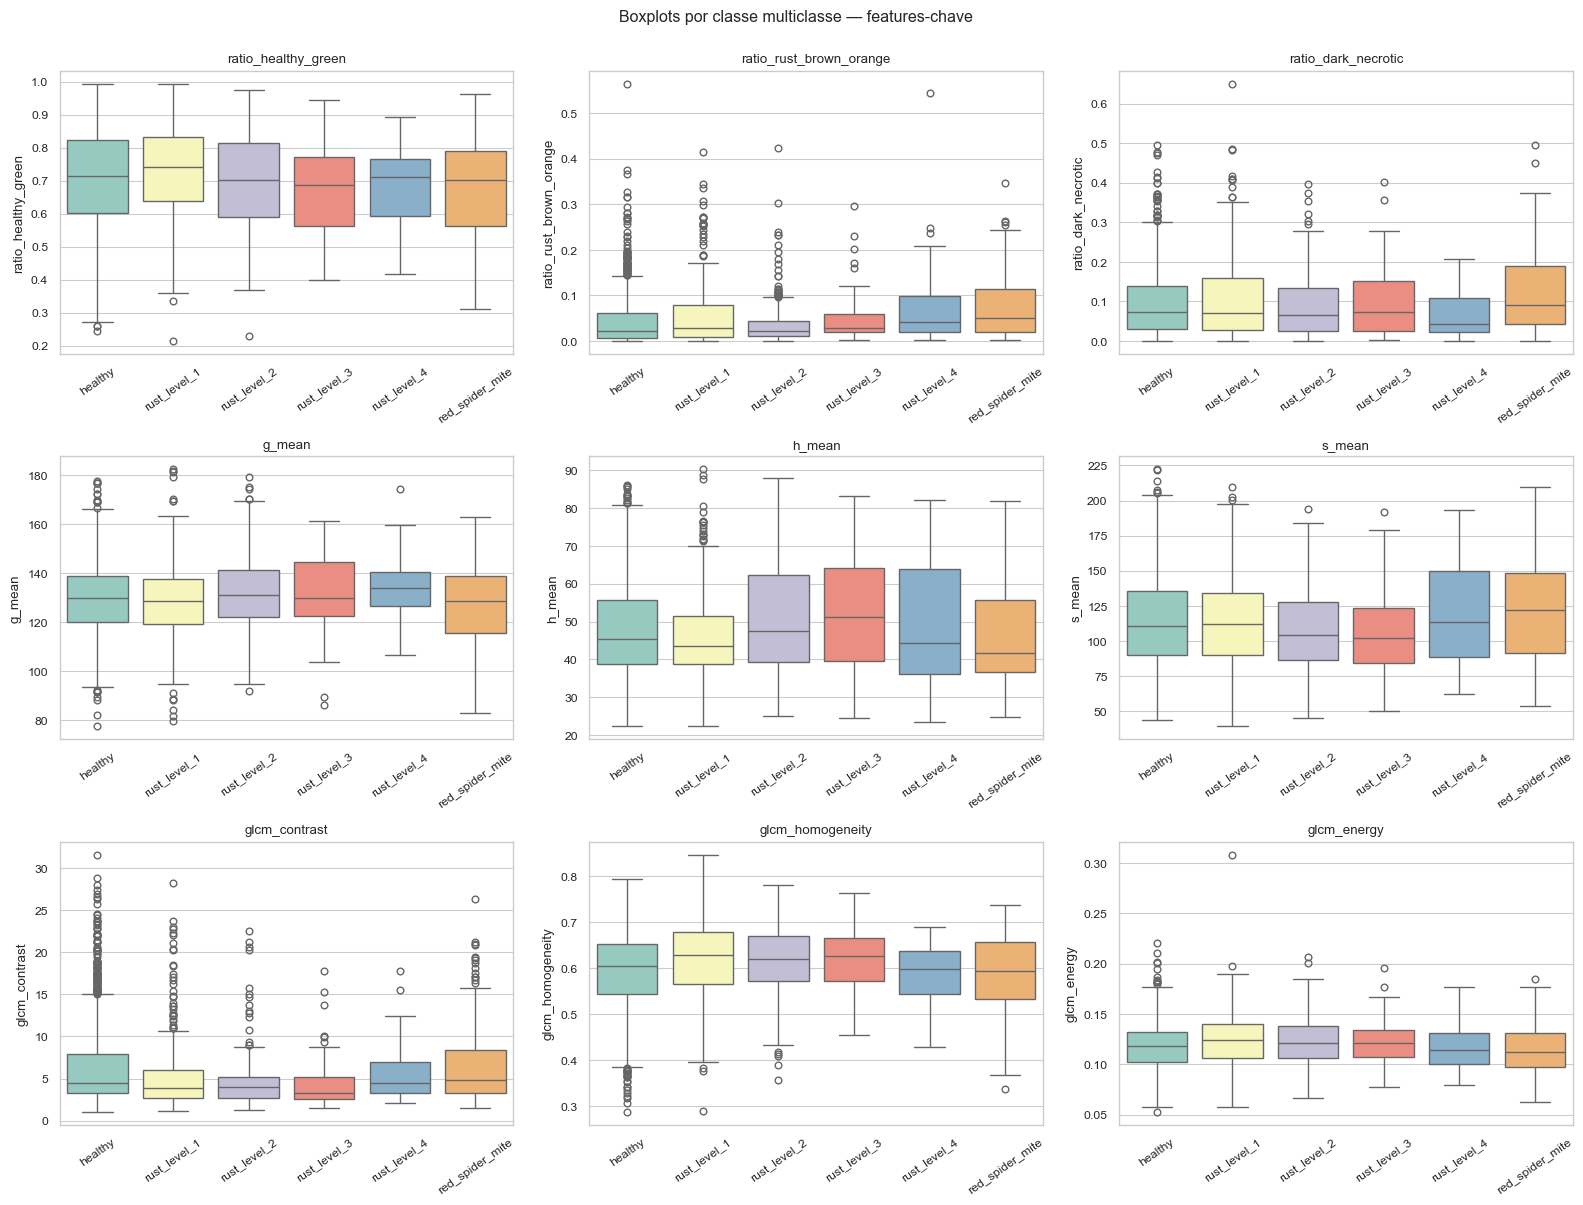

In [7]:
KEY_FEATS = ['ratio_healthy_green', 'ratio_rust_brown_orange', 'ratio_dark_necrotic',
             'g_mean', 'h_mean', 's_mean',
             'glcm_contrast', 'glcm_homogeneity', 'glcm_energy']

mc_order = ['healthy', 'rust_level_1', 'rust_level_2', 'rust_level_3', 'rust_level_4', 'red_spider_mite']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, feat in zip(axes.flat, KEY_FEATS):
    sns.boxplot(data=df, x='multiclass_label', y=feat, order=mc_order, ax=ax, palette='Set3')
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=35)
    ax.set_xlabel('')
plt.suptitle('Boxplots por classe multiclasse — features-chave', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'boxplots_keyfeats.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Matriz de correlação

Identifica redundâncias entre features — útil para seleção/redução na modelagem no KNIME.

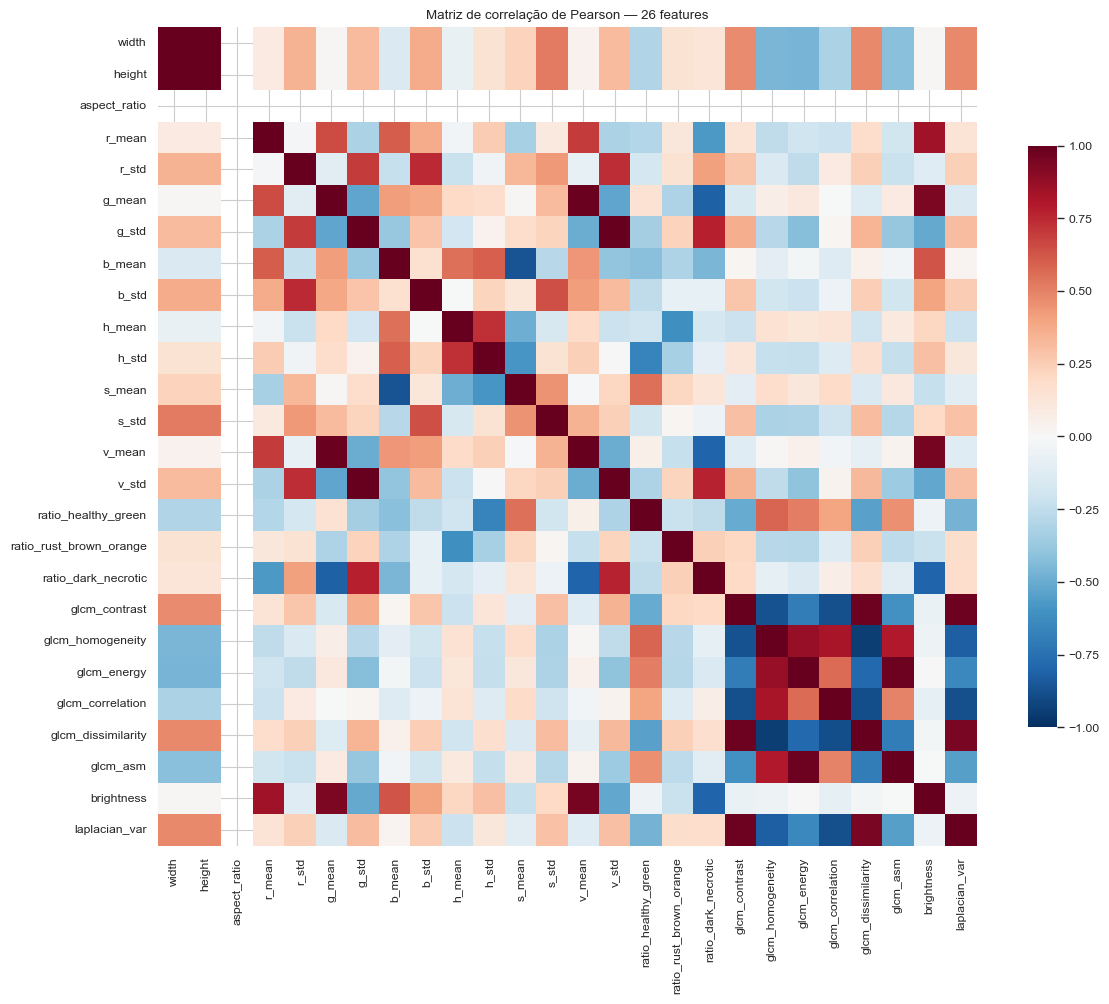

Top-10 pares mais correlacionados (|r|):
height              width                 1.000
g_std               v_std                 0.994
g_mean              v_mean                0.992
glcm_contrast       laplacian_var         0.982
glcm_asm            glcm_energy           0.981
glcm_contrast       glcm_dissimilarity    0.981
brightness          v_mean                0.957
glcm_dissimilarity  laplacian_var         0.951
                    glcm_homogeneity      0.949
brightness          g_mean                0.944
dtype: float64


In [8]:
corr = df[FEATURES].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Matriz de correlação de Pearson — 26 features')
plt.tight_layout()
plt.savefig(FIGS / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares mais correlacionados (em valor absoluto) — redundância candidata a ser removida.
pairs = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]
print('Top-10 pares mais correlacionados (|r|):')
print(pairs.head(10).round(3))

## 7. ANOVA — poder discriminativo de cada feature

Ranqueia features pelo F-score contra a classe multiclasse. Ajuda a priorizar variáveis para os modelos do KNIME.

                feature         F      p_value
                  width 13.958122 2.275406e-13
                 height 13.958122 2.275406e-13
       glcm_correlation  9.606744 4.816321e-09
          laplacian_var  8.910034 2.353530e-08
                  s_std  8.553323 5.293338e-08
     glcm_dissimilarity  8.490860 6.099704e-08
                  r_std  8.347707 8.440419e-08
            glcm_energy  8.297596 9.456169e-08
          glcm_contrast  8.165894 1.274554e-07
       glcm_homogeneity  8.013224 1.801032e-07
               glcm_asm  7.927203 2.188113e-07
ratio_rust_brown_orange  7.169725 1.209163e-06
                  v_std  6.795807 2.801248e-06
                  h_std  6.664545 3.759592e-06
                  g_std  6.152855 1.179302e-05
                 r_mean  5.370321 6.679044e-05
                 h_mean  5.167034 1.044385e-04
                  b_std  5.102402 1.203476e-04
                 b_mean  4.484617 4.622837e-04
                 s_mean  4.456239 4.915385e-04
    ratio_hea

/Users/natalia.salete/UFU-Mestrado/.venv/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [2] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/natalia.salete/UFU-Mestrado/.venv/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/var/folders/g8/73n4kmgs5_5dqn0b5h9hvf_00000gq/T/ipykernel_76598/671392670.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank, y='feature', x='F', palette='viridis', ax=ax)


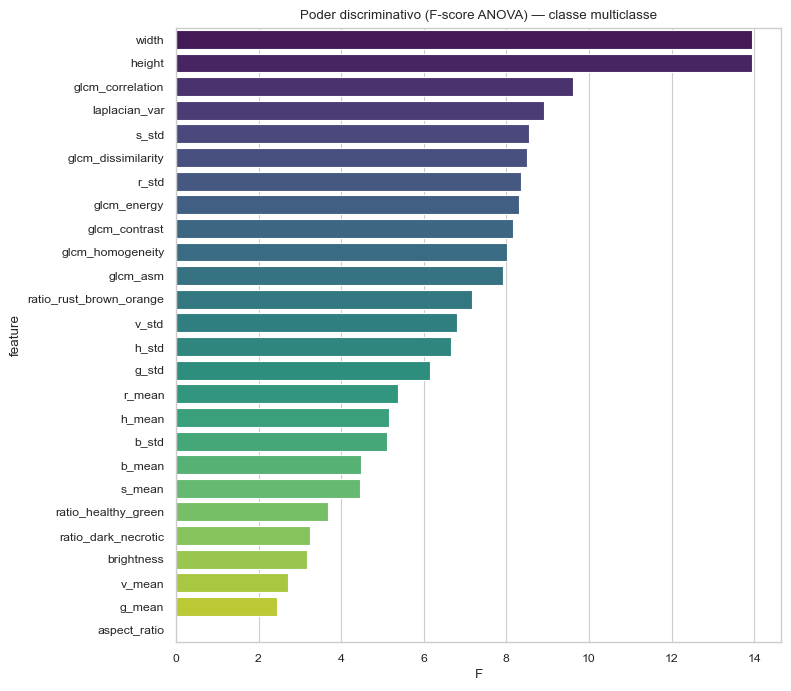

In [9]:
from sklearn.feature_selection import f_classif

X = df[FEATURES].values
y = df['multiclass_label'].values
F, p = f_classif(X, y)
rank = pd.DataFrame({'feature': FEATURES, 'F': F, 'p_value': p}).sort_values('F', ascending=False)
print(rank.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=rank, y='feature', x='F', palette='viridis', ax=ax)
ax.set_title('Poder discriminativo (F-score ANOVA) — classe multiclasse')
plt.tight_layout()
plt.savefig(FIGS / 'anova_fscore.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Visualização em baixa dimensão (PCA e t-SNE)

Permite ver, qualitativamente, se as classes são separáveis no espaço das 26 features.

/Users/natalia.salete/UFU-Mestrado/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/natalia.salete/UFU-Mestrado/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/natalia.salete/UFU-Mestrado/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/natalia.salete/UFU-Mestrado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/natalia.salete/UFU-Mestrado/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/natalia.salete/UFU-Mestrado/.venv/lib/python3.9/sit

Variância explicada PCA (2 comp): 55.59%


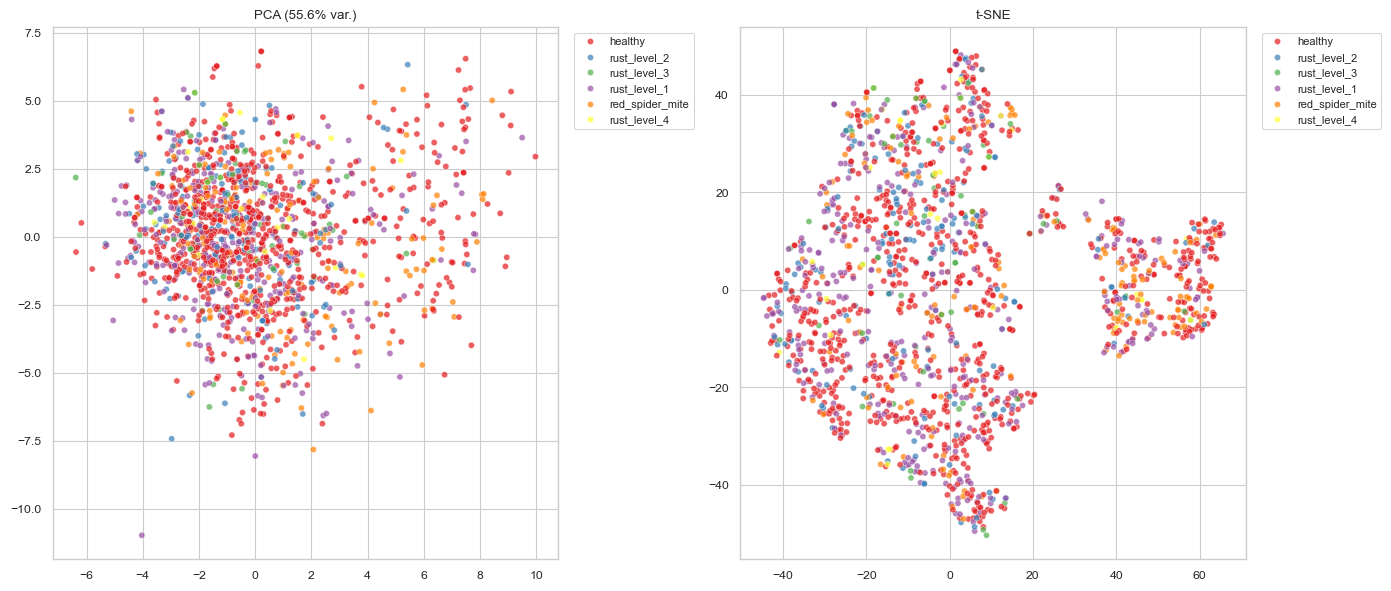

In [10]:
X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=0).fit(X_std)
proj_pca = pca.transform(X_std)
print(f'Variância explicada PCA (2 comp): {pca.explained_variance_ratio_.sum():.2%}')

proj_tsne = TSNE(n_components=2, random_state=0, perplexity=30, init='pca').fit_transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, proj, title in [(axes[0], proj_pca, f'PCA ({pca.explained_variance_ratio_.sum():.1%} var.)'),
                        (axes[1], proj_tsne, 't-SNE')]:
    sns.scatterplot(x=proj[:, 0], y=proj[:, 1], hue=df['multiclass_label'], palette='Set1', s=20, alpha=0.7, ax=ax)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'projections.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Síntese dos insights

Gera um resumo textual dos principais achados — é o que vai para a seção de AED do relatório.

In [11]:
n_total = len(df)
n_healthy = int((df['binary_label'] == 'healthy').sum())
n_unhealthy = n_total - n_healthy
minor = df['multiclass_label'].value_counts().min()
major = df['multiclass_label'].value_counts().max()
imbalance = major / minor

top3 = rank.head(3)['feature'].tolist()

print(f'Total de instâncias: {n_total}')
print(f'Saudáveis: {n_healthy} ({n_healthy/n_total:.1%}) | Doentes: {n_unhealthy} ({n_unhealthy/n_total:.1%})')
print(f'Razão de desbalanceamento multiclasse (maior/menor): {imbalance:.1f}x')
print(f'Features mais discriminativas (ANOVA): {top3}')
print(f'Dimensões: {df.width.min()}x{df.height.min()} a {df.width.max()}x{df.height.max()}')
print(f'Brilho médio: {df.brightness.mean():.1f} ± {df.brightness.std():.1f}')
print(f'Todos os artefatos salvos em: {FIGS}')

Total de instâncias: 1560
Saudáveis: 791 (50.7%) | Doentes: 769 (49.3%)
Razão de desbalanceamento multiclasse (maior/menor): 26.4x
Features mais discriminativas (ANOVA): ['width', 'height', 'glcm_correlation']
Dimensões: 720x1280 a 2322x4128
Brilho médio: 116.3 ± 13.9
Todos os artefatos salvos em: /Users/natalia.salete/UFU-Mestrado/TCD-Etapa1/outputs/figs
